In [83]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
import pmdarima as pm
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

Loading the data and getting familiar with it.

In [84]:
data_path = 'data/IBM_2006-01-01_to_2018-01-01.csv'

df = pd.read_csv(data_path)

df.describe()

,Open,High,Low,Close,Volume
count,3019.000000,3020.000000,3019.000000,3020.000000,3.020000e+03
mean,145.515545,146.681738,144.471597,145.617278,5.773301e+06
std,37.554946,37.613446,37.477641,37.529387,3.192831e+06
min,72.740000,73.940000,69.500000,71.740000,2.542560e+05
25%,116.405000,117.765000,115.490000,116.525000,3.622681e+06
50%,149.610000,150.330000,148.470000,149.315000,4.928852e+06
75%,178.445000,179.762500,177.330000,178.685000,6.965014e+06
max,215.380000,215.900000,214.300000,215.800000,3.077428e+07


Data preprocessing

In [85]:
# Filling missing dates with the previous day's values
first_date = df['Date'].min()
last_date = df['Date'].max()

# for single_date in pd.date_range(start=first_date, end=last_date):
#     if single_date.strftime('%Y-%m-%d') not in df['Date'].values:
#         previous_date = (single_date - pd.Timedelta(days=1)).strftime('%Y-%m-%d')
#         previous_row = df[df['Date'] == previous_date]
#         new_row = previous_row.copy()
#         new_row['Date'] = single_date.strftime('%Y-%m-%d')
#         new_row['Volume'] = 0
#         df = pd.concat([df, new_row], ignore_index=True)
# df = df.sort_values(by='Date').reset_index(drop=True)

# Find missing values in the data
missing_values = df.isnull().sum()
print("Missing values in each column:") 
print(missing_values)

# Fill missing values with previous day's values
df.fillna(method='ffill', inplace=True)

series = df["Open"]

# Split data into training and testing sets
train_size = int(len(series) * 0.8)
train, test = series[:train_size], series[train_size:]

Missing values in each column:
Date      0
Open      1
High      0
Low       1
Close     0
Volume    0
Name      0
dtype: int64


C:\Users\Eetu\AppData\Local\Temp\ipykernel_24004\2037005637.py:21: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


Extracting trend, seasonality and residuals from the time series data.

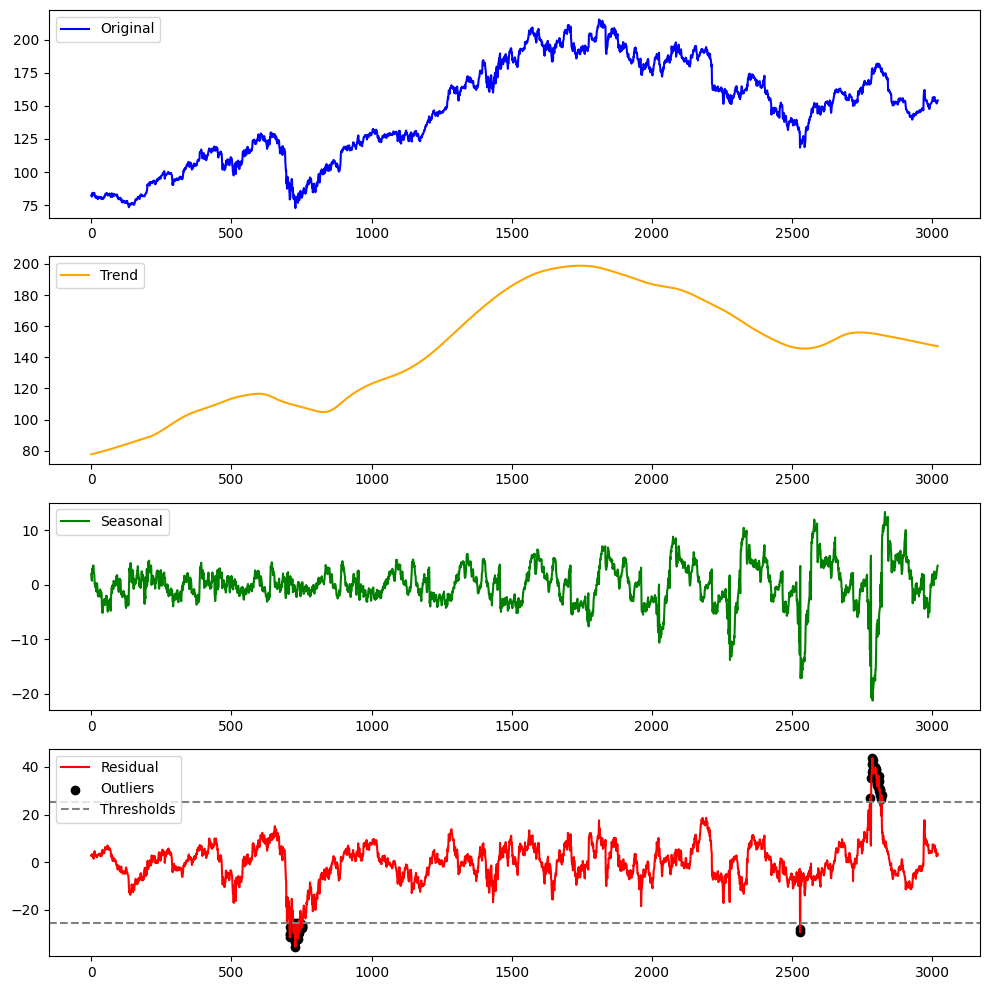

Number of outliers found: 68
Threshold: +/- 25.3331


In [ ]:
# use indexes instead of dates for STL decomposition
indexes = pd.RangeIndex(start=0, stop=len(df), step=1)

stl = STL(series, period=252, seasonal=13, robust=True)

res = stl.fit()

trend = res.trend
seasonal = res.seasonal
resid = res.resid

# Find outliers in the residuals using Z-score method
mu = resid.mean()
sigma = resid.std()
threshold = 3 * sigma

# Find Outliers
outliers = resid[np.abs(resid) > threshold]

plt.figure(figsize=(10, 10))
plt.subplot(4, 1, 1)
plt.plot(indexes, series, label='Original', color='blue')
plt.legend(loc='upper left')
plt.subplot(4, 1, 2)
plt.plot(indexes, trend, label='Trend', color='orange')
plt.legend(loc='upper left')
plt.subplot(4, 1, 3)
plt.plot(indexes, seasonal, label='Seasonal', color='green')
plt.legend(loc='upper left')
plt.subplot(4, 1, 4)
plt.plot(indexes, resid, label='Residual', color='red')
plt.scatter(indexes[outliers.index], outliers, color='black', label='Outliers')
plt.axhline(y=threshold, color='gray', linestyle='--', label='Thresholds')
plt.axhline(y=-threshold, color='gray', linestyle='--')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

print(f"Number of outliers found: {len(outliers)}")
print(f"Threshold: +/- {threshold:.4f}")

Plotting raw data for opening prices and volumes.

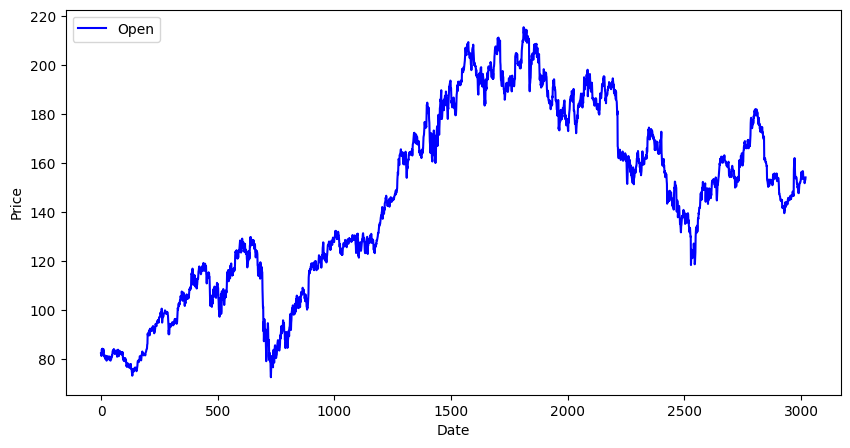

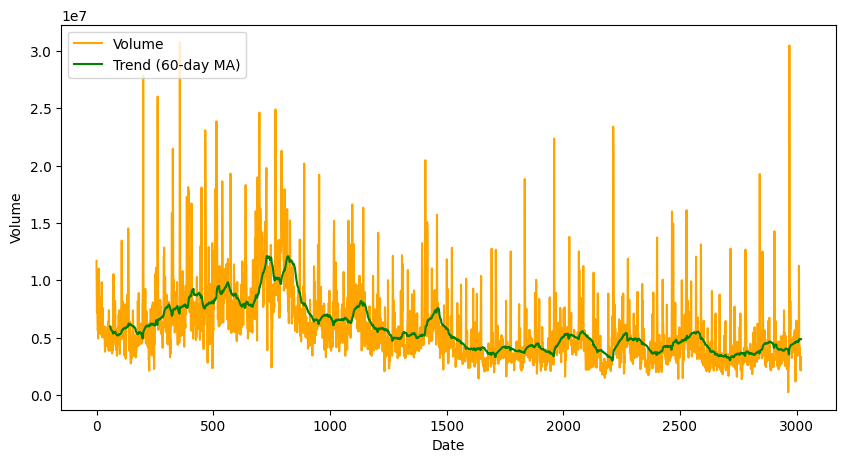

In [5]:
plt.figure(figsize=(10, 5))
plt.plot(indexes, series, label='Open', color='blue')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend(loc='upper left')
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(indexes, df['Volume'][series.index], label='Volume', color='orange')
trend_volume = df['Volume'][series.index].rolling(window=60).mean()
plt.plot(indexes, trend_volume, label='Trend (60-day MA)', color='green')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.legend(loc='upper left')
plt.show()

Autocorrelation analysis

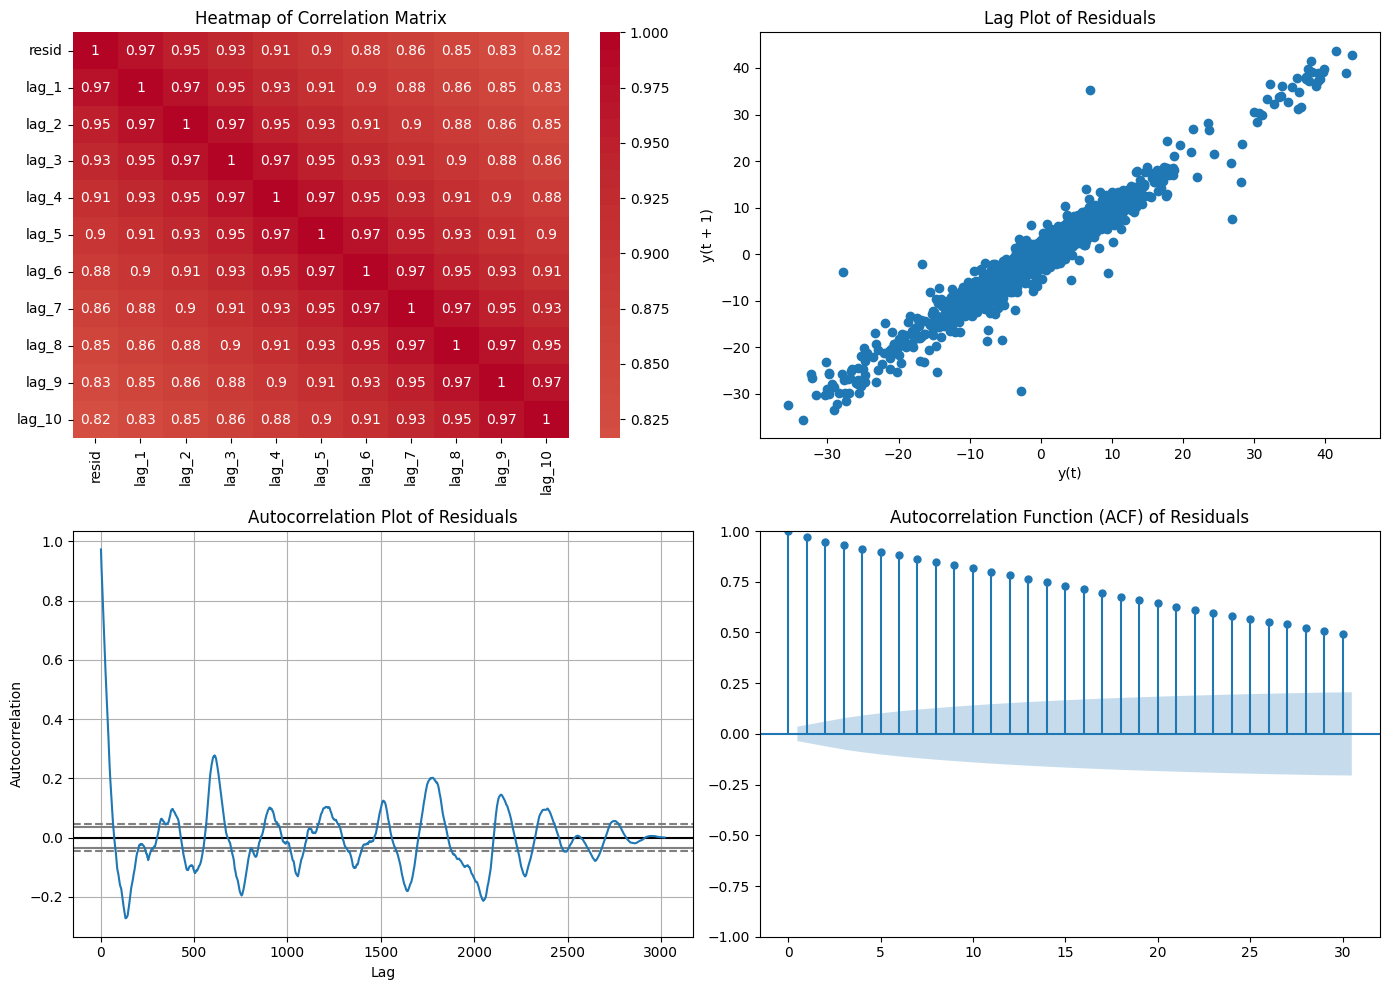

In [6]:
# Create a 1-10 day lagged dataset of the residuals
lagged_resid = pd.DataFrame({'resid': resid})
for i in range(1, 11):
    lagged_resid[f'lag_{i}'] = lagged_resid['resid'].shift(i)
lagged_resid = lagged_resid.dropna()

# Compute the correlation matrix
corr = lagged_resid.corr()
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Heatmap
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, ax=axes[0, 0])
axes[0, 0].set_title('Heatmap of Correlation Matrix')

# Lag plot
pd.plotting.lag_plot(resid, ax=axes[0, 1])
axes[0, 1].set_title('Lag Plot of Residuals')

# Autocorrelation plot
pd.plotting.autocorrelation_plot(resid, ax=axes[1, 0])
axes[1, 0].set_title('Autocorrelation Plot of Residuals')

# ACF (from statsmodels)
plot_acf(resid, lags=30, ax=axes[1, 1])
axes[1, 1].set_title('Autocorrelation Function (ACF) of Residuals')

plt.tight_layout()
plt.show()

Analyze returns

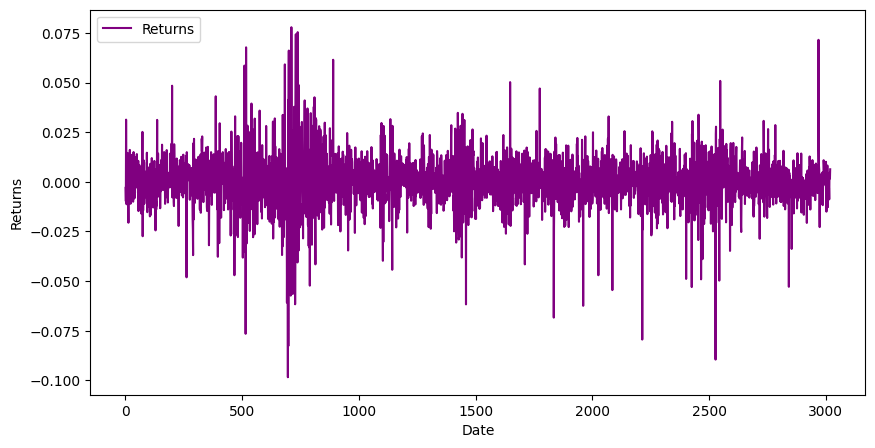

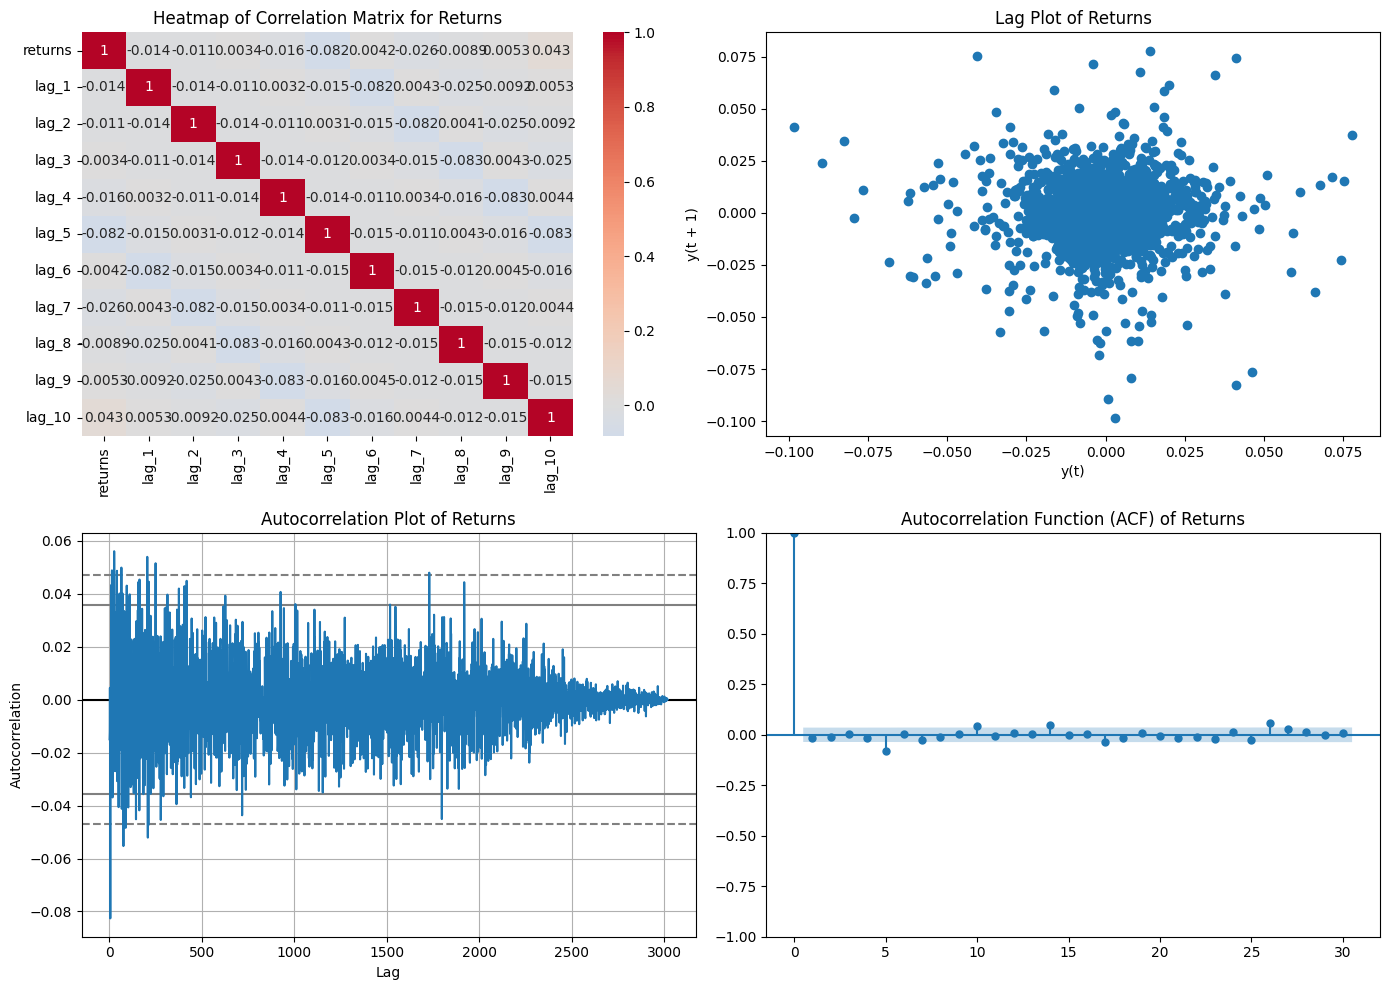

In [7]:
# Calculate returns
returns = series.pct_change().dropna()
plt.figure(figsize=(10, 5))
plt.plot(indexes[1:], returns, label='Returns', color='purple')
# plt.title('Stock Returns Over Time')
plt.xlabel('Date')
plt.ylabel('Returns')
plt.legend()
plt.show()

# Autocorrelation of returns
# Create a 1-10 day lagged dataset
lagged_returns = pd.DataFrame({'returns': returns})
for i in range(1, 11):
    lagged_returns[f'lag_{i}'] = lagged_returns['returns'].shift(i)
lagged_returns = lagged_returns.dropna()

# Compute the correlation matrix
corr_returns = lagged_returns.corr()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
# Heatmap
sns.heatmap(corr_returns, annot=True, cmap='coolwarm', center=0, ax=axes[0, 0])
axes[0, 0].set_title('Heatmap of Correlation Matrix for Returns')
# Lag plot
pd.plotting.lag_plot(returns, ax=axes[0, 1])
axes[0, 1].set_title('Lag Plot of Returns')
# Autocorrelation plot
pd.plotting.autocorrelation_plot(returns, ax=axes[1, 0])
axes[1, 0].set_title('Autocorrelation Plot of Returns')
# ACF (from statsmodels)
plot_acf(returns, lags=30, ax=axes[1, 1])
axes[1, 1].set_title('Autocorrelation Function (ACF) of Returns')
plt.tight_layout()
plt.show()

## ARIMA Model

Forecasting of the prices

Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,0,1)[7] intercept   : AIC=9740.501, Time=1.01 sec
 ARIMA(0,1,0)(0,0,0)[7] intercept   : AIC=9745.277, Time=0.03 sec
 ARIMA(1,1,0)(1,0,0)[7] intercept   : AIC=9742.056, Time=0.21 sec
 ARIMA(0,1,1)(0,0,1)[7] intercept   : AIC=9742.584, Time=0.20 sec
 ARIMA(0,1,0)(0,0,0)[7]             : AIC=9743.952, Time=0.03 sec
 ARIMA(1,1,1)(0,0,0)[7] intercept   : AIC=9742.173, Time=0.38 sec
 ARIMA(1,1,1)(1,0,1)[7] intercept   : AIC=9740.101, Time=1.40 sec
 ARIMA(1,1,1)(1,0,0)[7] intercept   : AIC=9740.239, Time=0.85 sec
 ARIMA(1,1,1)(2,0,1)[7] intercept   : AIC=9741.194, Time=2.64 sec
 ARIMA(1,1,1)(1,0,2)[7] intercept   : AIC=9741.092, Time=3.09 sec
 ARIMA(1,1,1)(0,0,2)[7] intercept   : AIC=9739.573, Time=1.86 sec
 ARIMA(0,1,1)(0,0,2)[7] intercept   : AIC=9740.413, Time=0.49 sec
 ARIMA(1,1,0)(0,0,2)[7] intercept   : AIC=9740.404, Time=0.42 sec
 ARIMA(2,1,1)(0,0,2)[7] intercept   : AIC=9744.045, Time=0.94 sec
 ARIMA(1,1,2)(0,0,2)[7] intercept

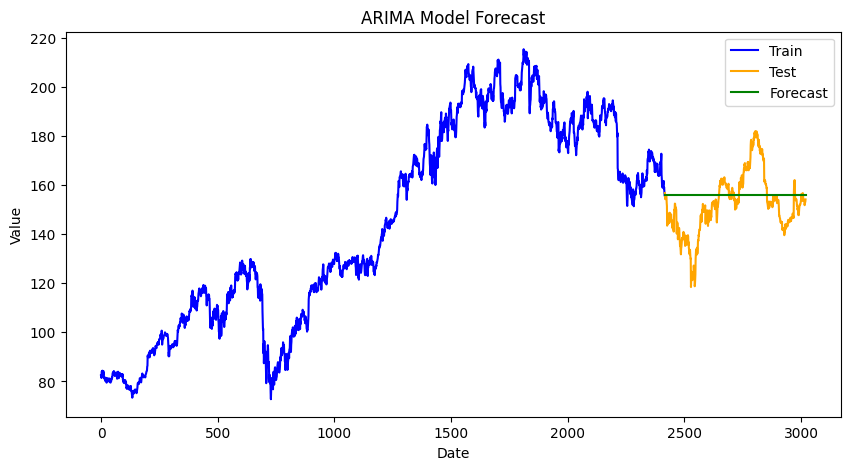

RMSE: 12.861992097979096
MAE: 10.079735099337743
R2 Score: -0.08721794410302719


In [8]:
# Split data into training and testing sets
train_size = int(len(series) * 0.8)
train, test = series[:train_size], series[train_size:]

auto_model = pm.auto_arima(train,
                           start_p=1, start_q=1,
                           test='adf',       # Use 'adf' test to find the optimal 'd'
                           max_p=5, max_q=5, # Maximum p and q
                           m=7,              # Seasonality
                           d=None,           # Let the test determine 'd'
                           seasonal=True,    # Seasonality
                           start_P=0,
                           D=0,
                           trace=True,
                           error_action='ignore',
                           suppress_warnings=True,
                           stepwise=True)

# Best order
best_order = auto_model.order
print(f"Best Order: {best_order}")

# Fit ARIMA model
model = ARIMA(train, order=best_order)
model_fit = model.fit()
# Forecast
forecast = model_fit.forecast(steps=len(test))
# Plot results
plt.figure(figsize=(10, 5))
plt.plot(train.index, train, label='Train', color='blue')
plt.plot(test.index, test, label='Test', color='orange')
plt.plot(test.index, forecast, label='Forecast', color='green')
plt.xlabel('Date')
plt.ylabel('Value')
plt.title('ARIMA Model Forecast')
plt.legend()
plt.show()

# Calculate the RMSE, MAE and R2 Score
rmse = root_mean_squared_error(test, forecast)
mae = mean_absolute_error(test, forecast)
r2 = r2_score(test, forecast)

print(f"RMSE: {rmse}")
print(f"MAE: {mae}")
print(f"R2 Score: {r2}")

Forecasting of the STL residuals

Best Order for Residuals: (1, 0, 1)
Best Order for Trend: (2, 1, 3)


c:\Users\Eetu\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


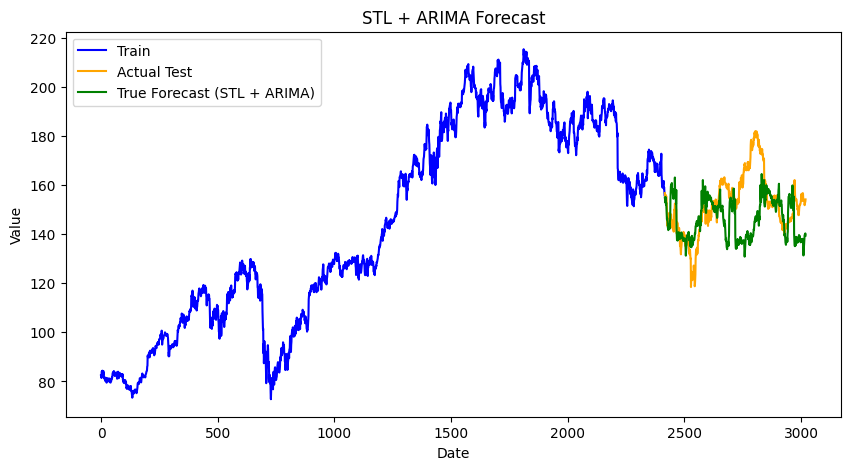

RMSE (Hybrid): 15.158222193527731
MAE (Hybrid): 11.288690340742907
R2 Score (Hybrid): -0.5100685837134498


In [10]:
# Split data into training and testing sets
train_size = int(len(series) * 0.8)
train, test = series[:train_size], series[train_size:]

# Original series splits
train_series, test_series = series[:train_size], series[train_size:]

period = 252
seasonal = 13
stl_train = STL(train_series, period=period, seasonal=seasonal, robust=True)
res_train = stl_train.fit()
n_periods = len(test_series)

# ARIMA on Residuals
auto_model_resid = pm.auto_arima(res_train.resid,
                                 start_p=1, start_q=1,
                                 test='adf',
                                 max_p=5, max_q=5,
                                 m=7, seasonal=True,
                                 d=None, D=0,
                                 trace=False,
                                 error_action='ignore',
                                 suppress_warnings=True,
                                 stepwise=True)

best_order_resid = auto_model_resid.order
print(f"Best Order for Residuals: {best_order_resid}")

model_resid = ARIMA(res_train.resid, order=best_order_resid)
model_resid_fit = model_resid.fit()

resid_forecast = pd.Series(model_resid_fit.forecast(steps=n_periods), 
                             index=test_series.index)

# ARIMA on Trend
auto_model_trend = pm.auto_arima(res_train.trend,
                                 start_p=1, start_q=1,
                                 d=1,
                                 max_p=3, max_q=3,
                                 seasonal=False, # No seasonality in the trend
                                 trace=False,
                                 error_action='ignore',
                                 suppress_warnings=True,
                                 stepwise=True)

best_order_trend = auto_model_trend.order
print(f"Best Order for Trend: {best_order_trend}")

model_trend = ARIMA(res_train.trend, order=best_order_trend)
model_trend_fit = model_trend.fit()

trend_forecast = pd.Series(model_trend_fit.forecast(steps=n_periods), 
                             index=test_series.index)

# Seasonal Forecasting by repeating the last observed seasonal cycle
last_season = res_train.seasonal[-period:]
num_reps = int(np.ceil(n_periods / period))
seasonal_forecast_tiled = np.tile(last_season, num_reps)
# Trim to the exact length of the test set
seasonal_forecast = pd.Series(seasonal_forecast_tiled[:n_periods], 
                                index=test_series.index)

# Combine forecasts
total_forecast = trend_forecast + seasonal_forecast + resid_forecast

# --- 6. Plot Results ---
plt.figure(figsize=(10, 5))
plt.plot(train_series, label='Train', color='blue')
plt.plot(test_series, label='Actual Test', color='orange')
plt.plot(total_forecast, label='True Forecast (STL + ARIMA)', color='green')
plt.xlabel('Date')
plt.ylabel('Value')
plt.title('STL + ARIMA Forecast')
plt.legend()
plt.show()

# Calculate the RMSE, MAE and R2 Score for the hybrid model
rmse_hybrid = root_mean_squared_error(test_series, total_forecast)
mae_hybrid = mean_absolute_error(test_series, total_forecast)
r2_hybrid = r2_score(test_series, total_forecast)

print(f"RMSE (Hybrid): {rmse_hybrid}")
print(f"MAE (Hybrid): {mae_hybrid}")
print(f"R2 Score (Hybrid): {r2_hybrid}")

## RNN and LSTM Models

In [86]:
# RNN Model
class RNNModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super(RNNModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True, dropout=0.3)
        self.fc_layers = nn.Sequential(
            nn.Linear(hidden_size, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, output_size)
        )

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        out, _ = self.rnn(x, h0)
        out = self.fc_layers(out[:, -1, :])
        return out
    
# LSTM Model
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super(LSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=0.3)
        self.fc_layers = nn.Sequential(
            nn.Linear(hidden_size, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, output_size)
        )

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc_layers(out[:, -1, :])
        return out

In [87]:
# Create training, validation, and testing datasets
def get_train_val_test(data_X, data_y, n_past, n_future):
    X, y = [], []
    for i in range(len(data_X) - n_past - n_future + 1):
        X.append(data_X[i : i + n_past])
        y.append(data_y[i + n_past : i + n_past + n_future])
        
    X = np.array(X)
    y = np.array(y)    
        
    X_test = X[-1:]
    y_test = y[-1:]

    X_remaining = X[:-1]
    y_remaining = y[:-1]
    # Split remaining data into training and validation sets
    X_train, X_val, y_train, y_val = train_test_split(
        X_remaining, y_remaining, 
        test_size=0.2,   
        shuffle=False    
    )
    return X_train, y_train, X_val, y_val, X_test, y_test


y = df["Open"]

# Change date column to features
df["Date"] = pd.to_datetime(df["Date"])
df["DayOfWeek"] = df["Date"].dt.dayofweek
df["Month"] = df["Date"].dt.month
df["Year"] = df["Date"].dt.year

# Change cyclical features to sin and cos components
df['Day_Sin'] = np.sin(2 * np.pi * df['DayOfWeek'] / 7)
df['Day_Cos'] = np.cos(2 * np.pi * df['DayOfWeek'] / 7)
df['Month_Sin'] = np.sin(2 * np.pi * df['Month'] / 12)
df['Month_Cos'] = np.cos(2 * np.pi * df['Month'] / 12)

# Drop unnecessary columns
X = df.drop(columns=["Date", "Open", "Name", "DayOfWeek", "Month"])
n_features = X.shape[1]
non_cyclical_idx = [i for i, col in enumerate(X.columns) if col in ['High', 'Low', 'Close', 'Volume', 'Year']]
print(X.head())

# Create sequences
n_past = 63 # Use past 63 days (approx. 3 months of trading days)
n_future_5 = 5 # Predict next trading week
n_future_21 = 21 # Predict next trading month

X_train_5, y_train_5, X_val_5, y_val_5, X_test_5, y_test_5 = get_train_val_test(X.values, y, n_past, n_future_5)
X_train_21, y_train_21, X_val_21, y_val_21, X_test_21, y_test_21 = get_train_val_test(X.values, y, n_past, n_future_21)

# Normalize data with StandardScaler and only on non-cyclical features
scaler_X_5 = StandardScaler()
scaler_X_21 = StandardScaler()
scaler_y_5 = StandardScaler()
scaler_y_21 = StandardScaler()

# Fit scalers on training data
scaler_X_5.fit(X_train_5[:, :, non_cyclical_idx].reshape(-1, len(non_cyclical_idx)))
scaler_y_5.fit(y_train_5.reshape(-1, 1))

scaler_X_21.fit(X_train_21[:, :, non_cyclical_idx].reshape(-1, len(non_cyclical_idx)))
scaler_y_21.fit(y_train_21.reshape(-1, 1))

# Normalize 5 day dataset
for dataset in [(X_train_5, y_train_5), (X_val_5, y_val_5), (X_test_5, y_test_5)]:
    X_data, y_data = dataset
    # Normalize X
    X_data[:, :, non_cyclical_idx] = scaler_X_5.transform(
        X_data[:, :, non_cyclical_idx].reshape(-1, len(non_cyclical_idx))).reshape(X_data.shape[0], X_data.shape[1], len(non_cyclical_idx)
    )
    # Normalize y
    y_data[:] = scaler_y_5.transform(y_data.reshape(-1, 1)).reshape(y_data.shape)
    
# Normalize 21 day dataset    
for dataset in [(X_train_21, y_train_21), (X_val_21, y_val_21), (X_test_21, y_test_21)]:
    X_data, y_data = dataset
    # Normalize X
    X_data[:, :, non_cyclical_idx] = scaler_X_21.transform(
        X_data[:, :, non_cyclical_idx].reshape(-1, len(non_cyclical_idx))).reshape(X_data.shape[0], X_data.shape[1], len(non_cyclical_idx)
    )
    # Normalize y
    y_data[:] = scaler_y_21.transform(y_data.reshape(-1, 1)).reshape(y_data.shape)

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Using device: {device}")

# Create DataLoaders
batch_size = 16
train_dataset_5 = TensorDataset(torch.tensor(X_train_5, dtype=torch.float32), torch.tensor(y_train_5, dtype=torch.float32).to(device))
train_loader_5 = DataLoader(train_dataset_5, batch_size=batch_size, shuffle=True)
val_dataset_5 = TensorDataset(torch.tensor(X_val_5, dtype=torch.float32), torch.tensor(y_val_5, dtype=torch.float32).to(device))
val_loader_5 = DataLoader(val_dataset_5, batch_size=batch_size, shuffle=False)
test_dataset_5 = TensorDataset(torch.tensor(X_test_5, dtype=torch.float32), torch.tensor(y_test_5, dtype=torch.float32).to(device))
test_loader_5 = DataLoader(test_dataset_5, batch_size=1, shuffle=False)


train_dataset_21 = TensorDataset(torch.tensor(X_train_21, dtype=torch.float32), torch.tensor(y_train_21, dtype=torch.float32).to(device))
train_loader_21 = DataLoader(train_dataset_21, batch_size=batch_size, shuffle=True)
val_dataset_21 = TensorDataset(torch.tensor(X_val_21, dtype=torch.float32), torch.tensor(y_val_21, dtype=torch.float32).to(device))
val_loader_21 = DataLoader(val_dataset_21, batch_size=batch_size, shuffle=False)
test_dataset_21 = TensorDataset(torch.tensor(X_test_21, dtype=torch.float32), torch.tensor(y_test_21, dtype=torch.float32).to(device))
test_loader_21 = DataLoader(test_dataset_21, batch_size=1, shuffle=False)


    High    Low  Close    Volume  Year   Day_Sin   Day_Cos  Month_Sin  \
0  82.55  80.81  82.06  11715200  2006  0.781831  0.623490        0.5   
1  82.50  81.33  81.95   9840600  2006  0.974928 -0.222521        0.5   
2  82.90  81.00  82.50   7213500  2006  0.433884 -0.900969        0.5   
3  85.03  83.41  84.95   8197400  2006 -0.433884 -0.900969        0.5   
4  84.25  83.38  83.73   6858200  2006  0.000000  1.000000        0.5   

   Month_Cos  
0   0.866025  
1   0.866025  
2   0.866025  
3   0.866025  
4   0.866025  
Using device: cuda


### Functions

In [88]:
# Training function
def train_model(model, train_loader, val_loader, optimizer, criterion, num_epochs, type):
    model.to(device)
    best_val_loss = float('inf')
    all_train_losses = []
    all_val_losses = []
    for epoch in range(num_epochs):
        model.train()
        train_losses = []
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())
        
        val_losses = []
        model.eval()
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                val_losses.append(loss.item())
        
        avg_train_loss = np.mean(train_losses)
        avg_val_loss = np.mean(val_losses)
        if (epoch+1) % 10 == 0 or epoch == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")
        
        # Save the best model
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), f'best_model_{type}.pth')
    
        all_train_losses.append(avg_train_loss)
        all_val_losses.append(avg_val_loss)

    # Plot training and validation loss
    plt.figure(figsize=(10, 5))
    plt.plot(all_train_losses, label='Train Loss')
    plt.plot(all_val_losses, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.show()

    # Load the best model
    model.load_state_dict(torch.load(f'best_model_{type}.pth'))
    return model

# Evaluation function
def evaluate_model(model, test_loader, scaler_y):
    model.eval()
    predictions = []
    actuals = []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            # ensure X is on device for inference
            X_batch = X_batch.to(device)
            outputs = model(X_batch)
            # move tensors to CPU before converting to numpy to avoid the cuda->numpy error
            predictions.append(outputs.cpu().numpy())
            actuals.append(y_batch.cpu().numpy())
    predictions = np.vstack(predictions)
    actuals = np.vstack(actuals)
    # Inverse transform
    real_predictions = scaler_y.inverse_transform(predictions)
    real_actuals = scaler_y.inverse_transform(actuals)
    
    # Print evaluation metrics
    rmse = root_mean_squared_error(real_actuals, real_predictions)
    mae = mean_absolute_error(real_actuals, real_predictions)
    print(f"Test RMSE: {rmse:.4f}")
    print(f"Test MAE: {mae:.4f}")
    
    return real_predictions, real_actuals

### RNN 

Training 5-day RNN model...
Epoch [1/100], Train Loss: 0.4542, Val Loss: 0.3294
Epoch [10/100], Train Loss: 0.0208, Val Loss: 0.0071
Epoch [20/100], Train Loss: 0.0167, Val Loss: 0.0074
Epoch [30/100], Train Loss: 0.0146, Val Loss: 0.0073
Epoch [40/100], Train Loss: 0.0131, Val Loss: 0.0063
Epoch [50/100], Train Loss: 0.0131, Val Loss: 0.0066
Epoch [60/100], Train Loss: 0.0119, Val Loss: 0.0063
Epoch [70/100], Train Loss: 0.0115, Val Loss: 0.0062
Epoch [80/100], Train Loss: 0.0115, Val Loss: 0.0060
Epoch [90/100], Train Loss: 0.0111, Val Loss: 0.0065
Epoch [100/100], Train Loss: 0.0110, Val Loss: 0.0059


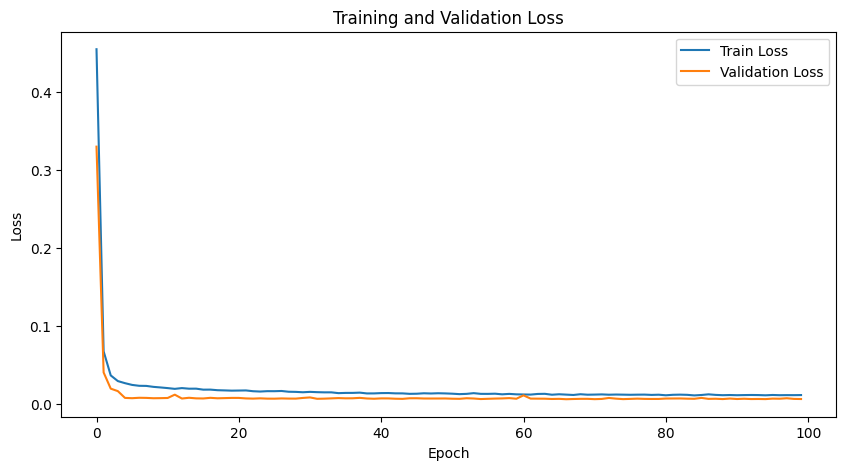

Training 21-day RNN model...
Epoch [1/100], Train Loss: 0.5671, Val Loss: 0.4558
Epoch [10/100], Train Loss: 0.0361, Val Loss: 0.0203
Epoch [20/100], Train Loss: 0.0307, Val Loss: 0.0204
Epoch [30/100], Train Loss: 0.0275, Val Loss: 0.0202
Epoch [40/100], Train Loss: 0.0256, Val Loss: 0.0209
Epoch [50/100], Train Loss: 0.0250, Val Loss: 0.0221
Epoch [60/100], Train Loss: 0.0228, Val Loss: 0.0247
Epoch [70/100], Train Loss: 0.0228, Val Loss: 0.0287
Epoch [80/100], Train Loss: 0.0216, Val Loss: 0.0340
Epoch [90/100], Train Loss: 0.0205, Val Loss: 0.0392
Epoch [100/100], Train Loss: 0.0204, Val Loss: 0.0387


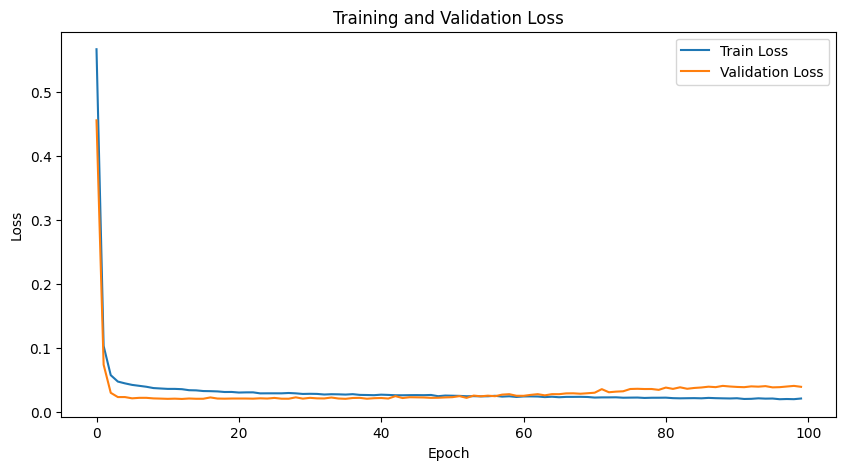

Evaluating 5-day RNN model...
Test RMSE: 0.9411
Test MAE: 0.9411
Evaluating 21-day RNN model...
Test RMSE: 2.4996
Test MAE: 2.4996


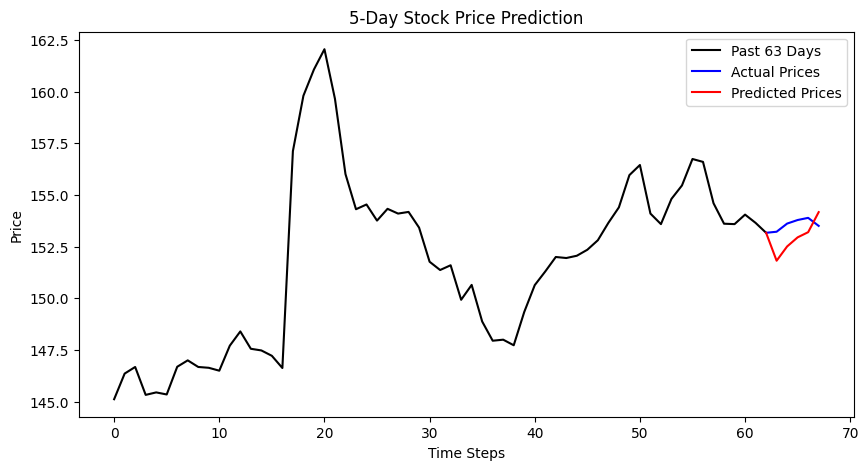

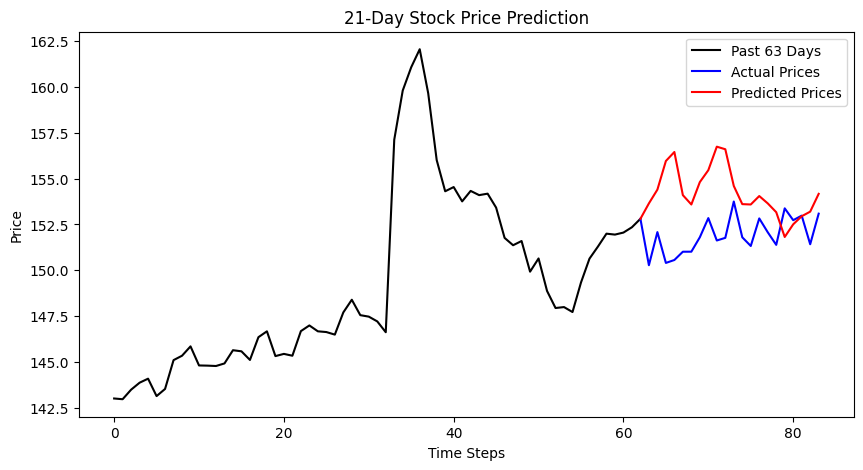

In [91]:
# Train the RNN model on both 5-day and 21-day datasets
model_5 = RNNModel(input_size=n_features, hidden_size=128, num_layers=2, output_size=n_future_5)
model_21 = RNNModel(input_size=n_features, hidden_size=128, num_layers=2, output_size=n_future_21)

num_epochs = 100
criterion = nn.MSELoss()
optimizer_5 = torch.optim.Adam(model_5.parameters(), lr=5e-5)
optimizer_21 = torch.optim.Adam(model_21.parameters(), lr=5e-5)

# Train models
print("Training 5-day RNN model...")
model_5 = train_model(model_5, train_loader_5, val_loader_5, optimizer_5, criterion, num_epochs, type='RNN 5-day')
print("Training 21-day RNN model...")
model_21 = train_model(model_21, train_loader_21, val_loader_21, optimizer_21, criterion, num_epochs, type='RNN 21-day')

# Evaluate models
print("Evaluating 5-day RNN model...")
simulated_prediction_5, y_test_5_real = evaluate_model(model_5, test_loader_5, scaler_y_5)
print("Evaluating 21-day RNN model...")
simulated_prediction_21, y_test_21_real = evaluate_model(model_21, test_loader_21, scaler_y_21)

# Plot the predictions connected to the past data 
past_63_days_5 = y[-63-5:-5].values
real_future_5 = y_test_5_real.flatten()
pred_future_5 = simulated_prediction_5.flatten()

# Connect the lines
plot_real_5 = np.insert(pred_future_5, 0, past_63_days_5[-1])
plot_pred_5 = np.insert(real_future_5, 0, past_63_days_5[-1])

x_past = np.arange(0, 63)
x_future_5 = np.arange(62, 62 + len(plot_real_5))

# PLOT 5-DAY
plt.figure(figsize=(10, 5))
plt.plot(x_past, past_63_days_5, label='Past 63 Days', color='black')
plt.plot(x_future_5, plot_real_5, label='Actual Prices', color='blue')
plt.plot(x_future_5, plot_pred_5, label='Predicted Prices', color='red')
plt.title('5-Day Stock Price Prediction')
plt.xlabel('Time Steps')
plt.ylabel('Price')
plt.legend()
plt.show()

past_63_days_21 = y[-63-21:-21].values
real_future_21 = y_test_21_real.flatten()
pred_future_21 = simulated_prediction_21.flatten()
plot_real_21 = np.insert(pred_future_21, 0, past_63_days_21[-1])
plot_pred_21 = np.insert(real_future_21, 0, past_63_days_21[-1])

x_future_21 = np.arange(62, 62 + len(plot_real_21))

# PLOT 21-DAY
plt.figure(figsize=(10, 5))
plt.plot(x_past, past_63_days_21, label='Past 63 Days', color='black')
plt.plot(x_future_21, plot_real_21, label='Actual Prices', color='blue')
plt.plot(x_future_21, plot_pred_21, label='Predicted Prices', color='red')
plt.title('21-Day Stock Price Prediction')
plt.xlabel('Time Steps')
plt.ylabel('Price')
plt.legend()
plt.show()

### LSTM Model

Training 5-day LSTM model...
Epoch [1/100], Train Loss: 0.7743, Val Loss: 0.2119
Epoch [10/100], Train Loss: 0.0226, Val Loss: 0.0109
Epoch [20/100], Train Loss: 0.0174, Val Loss: 0.0086
Epoch [30/100], Train Loss: 0.0159, Val Loss: 0.0082
Epoch [40/100], Train Loss: 0.0142, Val Loss: 0.0079
Epoch [50/100], Train Loss: 0.0137, Val Loss: 0.0075
Epoch [60/100], Train Loss: 0.0133, Val Loss: 0.0079
Epoch [70/100], Train Loss: 0.0124, Val Loss: 0.0074
Epoch [80/100], Train Loss: 0.0118, Val Loss: 0.0086
Epoch [90/100], Train Loss: 0.0118, Val Loss: 0.0086
Epoch [100/100], Train Loss: 0.0120, Val Loss: 0.0084


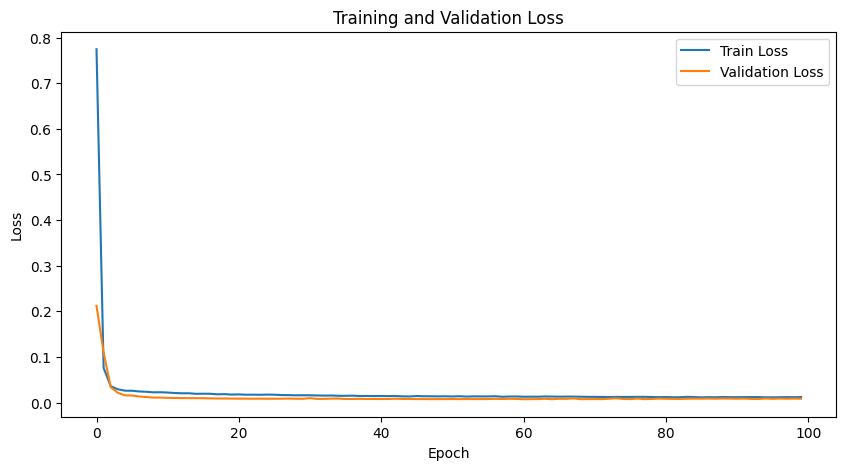

Training 21-day LSTM model...
Epoch [1/100], Train Loss: 0.8563, Val Loss: 0.1522
Epoch [10/100], Train Loss: 0.0349, Val Loss: 0.0268
Epoch [20/100], Train Loss: 0.0307, Val Loss: 0.0253
Epoch [30/100], Train Loss: 0.0268, Val Loss: 0.0250
Epoch [40/100], Train Loss: 0.0251, Val Loss: 0.0263
Epoch [50/100], Train Loss: 0.0237, Val Loss: 0.0291
Epoch [60/100], Train Loss: 0.0226, Val Loss: 0.0340
Epoch [70/100], Train Loss: 0.0206, Val Loss: 0.0407
Epoch [80/100], Train Loss: 0.0197, Val Loss: 0.0462
Epoch [90/100], Train Loss: 0.0190, Val Loss: 0.0479
Epoch [100/100], Train Loss: 0.0177, Val Loss: 0.0520


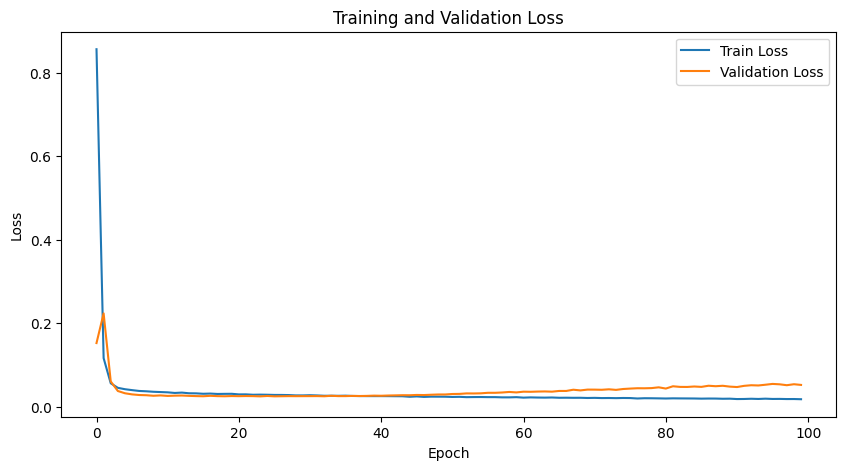

Evaluating 5-day LSTM model...
Test RMSE: 0.4749
Test MAE: 0.4749
Evaluating 21-day LSTM model...
Test RMSE: 3.7047
Test MAE: 3.7047


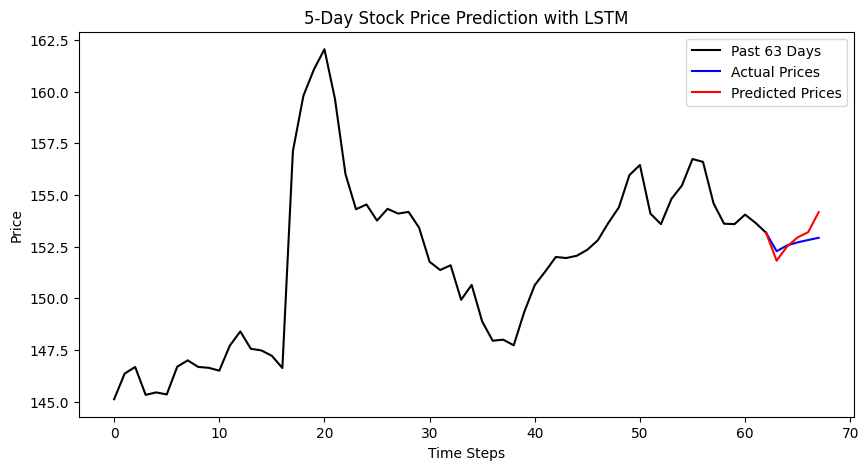

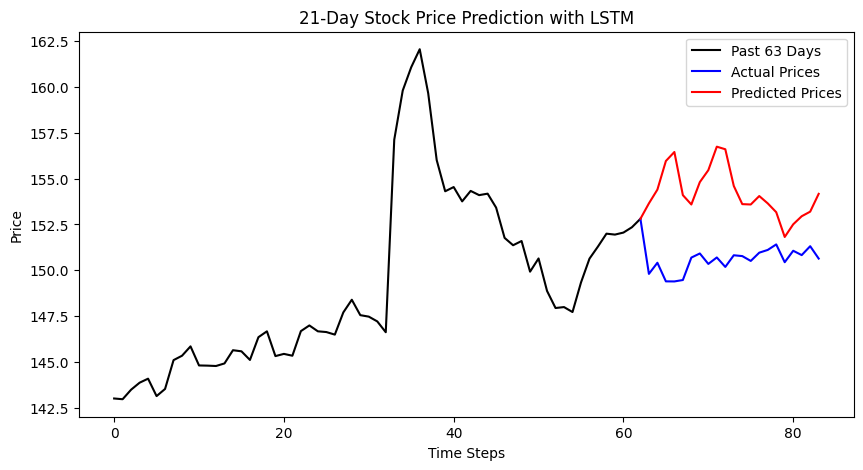

In [92]:
# Train the LSTM model on both 5-day and 21-day datasets
model_lstm_5 = LSTMModel(input_size=n_features, hidden_size=128, num_layers=2, output_size=n_future_5)
model_lstm_21 = LSTMModel(input_size=n_features, hidden_size=128, num_layers=2, output_size=n_future_21)

num_epochs = 100
criterion = nn.MSELoss()
optimizer_lstm_5 = torch.optim.Adam(model_lstm_5.parameters(), lr=5e-5)
optimizer_lstm_21 = torch.optim.Adam(model_lstm_21.parameters(), lr=5e-5)

# Train models
print("Training 5-day LSTM model...")
model_lstm_5 = train_model(model_lstm_5, train_loader_5, val_loader_5, optimizer_lstm_5, criterion, num_epochs, type='LSTM 5-day')
print("Training 21-day LSTM model...")
model_lstm_21 = train_model(model_lstm_21, train_loader_21, val_loader_21, optimizer_lstm_21, criterion, num_epochs, type='LSTM 21-day')

# Evaluate models
print("Evaluating 5-day LSTM model...")
simulated_prediction_lstm_5, y_test_lstm_5_real = evaluate_model(model_lstm_5, test_loader_5, scaler_y_5)
print("Evaluating 21-day LSTM model...")
simulated_prediction_lstm_21, y_test_lstm_21_real = evaluate_model(model_lstm_21, test_loader_21, scaler_y_21)

# Plot the predictions connected to the past data 
past_63_days_5 = y[-63-5:-5].values
real_future_lstm_5 = y_test_lstm_5_real.flatten()
pred_future_lstm_5 = simulated_prediction_lstm_5.flatten()
plot_real_lstm_5 = np.insert(pred_future_lstm_5, 0, past_63_days_5[-1])
plot_pred_lstm_5 = np.insert(real_future_lstm_5, 0, past_63_days_5[-1])
x_future_5 = np.arange(62, 62 + len(plot_real_lstm_5))

# PLOT 5-DAY LSTM
plt.figure(figsize=(10, 5))
plt.plot(x_past, past_63_days_5, label='Past 63 Days', color='black')
plt.plot(x_future_5, plot_real_lstm_5, label='Actual Prices', color='blue')
plt.plot(x_future_5, plot_pred_lstm_5, label='Predicted Prices', color='red')
plt.title('5-Day Stock Price Prediction with LSTM')
plt.xlabel('Time Steps')
plt.ylabel('Price')
plt.legend()
plt.show()

past_63_days_21 = y[-63-21:-21].values
real_future_lstm_21 = y_test_lstm_21_real.flatten()
pred_future_lstm_21 = simulated_prediction_lstm_21.flatten()
plot_real_lstm_21 = np.insert(pred_future_lstm_21, 0, past_63_days_21[-1])
plot_pred_lstm_21 = np.insert(real_future_lstm_21, 0, past_63_days_21[-1])
x_future_21 = np.arange(62, 62 + len(plot_real_lstm_21))

# PLOT 21-DAY LSTM
plt.figure(figsize=(10, 5))
plt.plot(x_past, past_63_days_21, label='Past 63 Days', color='black')
plt.plot(x_future_21, plot_real_lstm_21, label='Actual Prices', color='blue')
plt.plot(x_future_21, plot_pred_lstm_21, label='Predicted Prices', color='red')
plt.title('21-Day Stock Price Prediction with LSTM')
plt.xlabel('Time Steps')
plt.ylabel('Price')
plt.legend()
plt.show()